In [ ]:
1 = 1
2 = 1 + 1
3 = (1 + 1) + 1
4 = (1 + 1) * (1 + 1)
5 = ((1 + 1) * (1 + 1)) + 1
6 = (1 + 1) * ((1 + 1) + 1)
7 = (1 + 1) * ((1 + 1) + 1) + 1
8 = (1 + 1) * (1 + 1) * (1 + 1)
9 = ((1 + 1) + 1) * ((1 + 1) + 1)

{times[power[1, 1]], times[power[2, 1]], times[power[3, 1]], times[power[2, 2]], 
 
>   times[power[5, 1]], times[power[2, 1], power[3, 1]], times[power[7, 1]], 
 
>   times[power[2, 3]], times[power[3, 2]], times[power[2, 1], power[5, 1]], 
 
>   times[power[11, 1]], times[power[2, 2], power[3, 1]], times[power[13, 1]], 
 
>   times[power[2, 1], power[7, 1]], times[power[3, 1], power[5, 1]], times[power[2, 4]]}
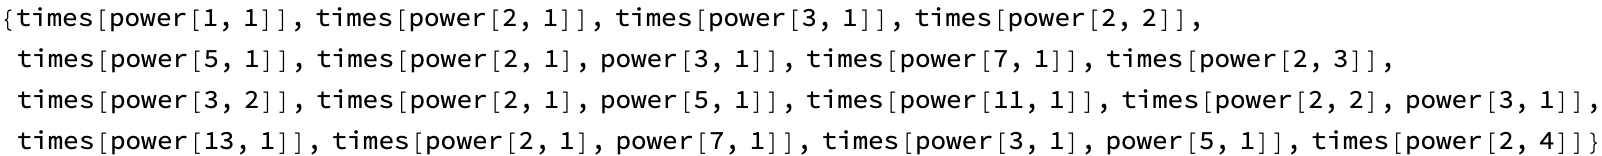

In [16]:
Table[Inner[power, Sequence @@ Transpose[FactorInteger[i]], times], {i, 16}]

In [57]:
timesInteger[n_] := Inner[ConstantArray, Sequence @@ Transpose[FactorInteger[n]], Join]

In [58]:
Table[timesInteger[i], {i, 16}]

{{1}, {2}, {3}, {2, 2}, {5}, {2, 3}, {7}, {2, 2, 2}, {3, 3}, {2, 5}, {11}, {2, 2, 3}, 
 
>   {13}, {2, 7}, {3, 5}, {2, 2, 2, 2}}

In [168]:
integerTree[1] := {}
integerTree[n_?PrimeQ] := {integerTree[n - 1]}
integerTree[n_] := integerTree /@ timesInteger[n]

1    {}

2    {{}}

3    {{{}}}

4    {{{}}, {{}}}

5    {{{{}}, {{}}}}

6    {{{}}, {{{}}}}

7    {{{{}}, {{{}}}}}

8    {{{}}, {{}}, {{}}}

9    {{{{}}}, {{{}}}}

10   {{{}}, {{{{}}, {{}}}}}

11   {{{{}}, {{{{}}, {{}}}}}}

12   {{{}}, {{}}, {{{}}}}

13   {{{{}}, {{}}, {{{}}}}}

14   {{{}}, {{{{}}, {{{}}}}}}

15   {{{{}}}, {{{{}}, {{}}}}}
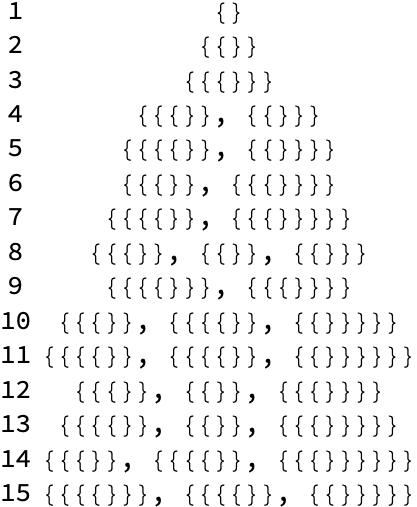

In [ ]:
Grid[Table[{i, ExportString[integerTree[i], "String"]}, {i, 15}]]

In [232]:
Table[{i, 
    ExportString[integerTree[i], "JSON", "Compact" -> True]
}, {i, 16}]

{{1, []}, {2, [[]]}, {3, [[[]]]}, {4, [[[]],[[]]]}, {5, [[[[]],[[]]]]}, 
 
>   {6, [[[]],[[[]]]]}, {7, [[[[]],[[[]]]]]}, {8, [[[]],[[]],[[]]]}, 
 
>   {9, [[[[]]],[[[]]]]}, {10, [[[]],[[[[]],[[]]]]]}, {11, [[[[]],[[[[]],[[]]]]]]}, 
 
>   {12, [[[]],[[]],[[[]]]]}, {13, [[[[]],[[]],[[[]]]]]}, {14, [[[]],[[[[]],[[[]]]]]]}, 
 
>   {15, [[[[]]],[[[[]],[[]]]]]}, {16, [[[]],[[]],[[]],[[]]]}}

In [ ]:
Export["~/temp/image.png", ArrayPlot[
    Reverse @ Transpose @ PadRight[
        Table[
            StringSplit[
                StringReplace[
                    ExportString[integerTree[i], "String"], {
                        " " -> "",
                        "{" -> "1",
                        "}" -> "0",
                        "," -> "0"
                    }
                ]
            , ""] /. {"1" -> 1, "0" -> 0},
        {i, 1024}]
    ]
, PixelConstrained -> 1, Frame -> False]]

~/temp/image.png